# 02. Cloudrunner Single Tile Processing Guide

This notebook demonstrates how to set up and test the cloudrunner toolset for LiDAR processing.


## SETUP


### Import Python Libraries

In [32]:
import pdal
import geopandas as gpd
import matplotlib.pyplot as plt

### Working Directory

In [30]:
# set the base working directory

wd = "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial"

# set up a few variables to edit
zmin = 280
zmax = 310
attribute_name = "Buffer"

### Project Variables

If that is set correctly, then the following subdirectories relative to the ```wd``` should not need to be edited.

In [42]:
# this can be left alone

# Create directory variables
lidar_dir  = f"{wd}/data/test"
raster_dir = f"{wd}/data/tif"
shapes_dir = f"{wd}/data/shp"

# Create file name variables
# ---------------------------
# lidar
las_name  = "ARS_Aspens_08242020_grid_lidar"
base_las  = f"{lidar_dir}/{las_name}"
las_file  = f"{base_las}.las"

# shapes
polyname = "aspens-comp-garden_buffer_poly"
polygon_file = f"{shapes_dir}/{polyname}.geojson"

# raster
rgb_file  = f"{raster_dir}/ARLINGTON-ARS_20200824_02_Refl_rgb_clip.tif"
swir_file = f"{raster_dir}/ARLINGTON-ARS_20200824_02_Refl_swir_clip.tif"

Use `pdal info` to look at the file properties.

The ` --metadata` flag will run faster and only grab the header information.

In [27]:
!pdal info {las_file} --metadata

{
  "file_size": 1023010736,
  "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar.las",
  "metadata":
  {
    "comp_spatialreference": "PROJCS[\"WGS 84 / UTM zone 16N\",GEOGCS[\"WGS 84\",DATUM[\"WGS_1984\",SPHEROID[\"WGS 84\",6378137,298.257223563,AUTHORITY[\"EPSG\",\"7030\"]],AUTHORITY[\"EPSG\",\"6326\"]],PRIMEM[\"Greenwich\",0,AUTHORITY[\"EPSG\",\"8901\"]],UNIT[\"degree\",0.0174532925199433,AUTHORITY[\"EPSG\",\"9122\"]],AUTHORITY[\"EPSG\",\"4326\"]],PROJECTION[\"Transverse_Mercator\"],PARAMETER[\"latitude_of_origin\",0],PARAMETER[\"central_meridian\",-87],PARAMETER[\"scale_factor\",0.9996],PARAMETER[\"false_easting\",500000],PARAMETER[\"false_northing\",0],UNIT[\"metre\",1,AUTHORITY[\"EPSG\",\"9001\"]],AXIS[\"Easting\",EAST],AXIS[\"Northing\",NORTH],AUTHORITY[\"EPSG\",\"32616\"]]",
    "compressed": false,
    "copc": false,
    "count": 36536082,
    "creation_doy": 238,
    "creation_year": 2020,
    "dataformat_id": 1,
    "data

The main function will return the cloud stats and attribute information.

In [28]:
%%time
!pdal info {las_file}

{
  "file_size": 1023010736,
  "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar.las",
  "now": "2025-04-28T20:30:36-0500",
  "pdal_version": "2.8.4 (git-version: 412c57)",
  "reader": "readers.las",
  "stats":
  {
    "bbox":
    {
      "EPSG:4326":
      {
        "bbox":
        {
          "maxx": -89.36379011,
          "maxy": 43.29089448,
          "maxz": 397.873,
          "minx": -89.36763761,
          "miny": 43.28814034,
          "minz": 229.644
        },
        "boundary": { "type": "Polygon", "coordinates": [ [ [ -89.367533726317546, 43.288140337127032, 229.644 ], [ -89.367637606285911, 43.290817005394466, 229.644 ], [ -89.363893821666039, 43.29089447883959, 397.873 ], [ -89.363790105582751, 43.28821780336947, 397.873 ], [ -89.367533726317546, 43.288140337127032, 229.644 ] ] ] }
      },
      "native":
      {
        "bbox":
        {
          "maxx": 308231.014,
          "maxy": 4795832.379,
          "maxz":

## 1. Create Functions

Functions for plotting that are not present in the code base. These can help reduce code overhead for repetitive tasks.

In [124]:
# Custom functions

# Create Rasterio function to read raster
def rio_read(file,bands=[1,2,3]):
    import rasterio
    with rasterio.open(file) as src:
        raster = src.read(bands) # Read the red, green, and blue bands
        transform = src.transform
        return raster, transform


# Create a function for plotting the point cloud
def plot_cloud(arrays, zlims=[0,25], zlabel = "Height Above Ground", point_thresh=500000, mark='.', cmap='jet', fig_size=(8,8), pt_alpha=.7):
    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(111, projection='3d')

    # - Access the x, y, z points as numpy arrays
    # - use point threshold to limit the number of points plotted
    x = arrays['X'][:point_thresh]
    y = arrays['Y'][:point_thresh]
    z = arrays['Z'][:point_thresh]

    # - Create the scatter plot, coloring by z value
    scatter = ax.scatter(x, y, z, c=z, cmap=cmap, marker=mark, alpha=pt_alpha)

    # - Add a colorbar
    cbar = fig.colorbar(scatter)

    # - Set the colorbar label
    cbar.set_label('Height Above Ground (m)', fontsize=10)

    # - Set labels for the axes
    ax.set_xlabel('X - Northing (m)')
    ax.set_ylabel('Y - Easting (m)')
    ax.set_zlabel(f'Z - {zlabel}  (m)', fontsize=9)
    ax.set_title("Lidar Point Cloud", fontsize=12)

    # - Set height Z-axis limits
    ax.set_zlim(zlims[0], zlims[1])

    # - Show the plot with tight layout
    plt.tight_layout()
    plt.show()

    return fig, ax

## 2. Support Shapes

Vector files can be used to clip point clouds.

There is a single attribute of "Buffer" where the outer Buffer = 1 and the main tile is Buffer = 0.

,Buffer,geometry
0,0,"MULTIPOLYGON (((308087.633 4795704.687, 308089..."
1,1,"MULTIPOLYGON (((308036.301 4795704.244, 308037..."


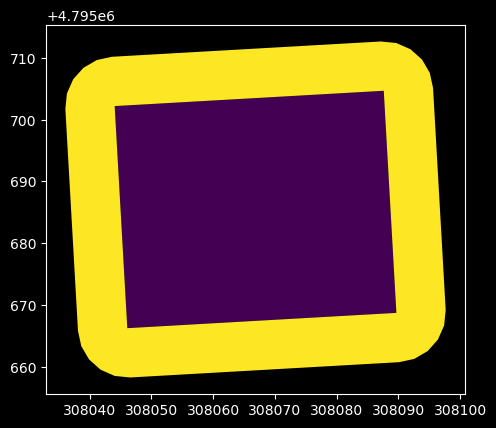

In [18]:
polygon = gpd.read_file(polygon_file)

polygon.plot(column="Buffer")

polygon

## 3. PDAL Pipeline

### Initialize

Create an empty pipeline object.

In [161]:
clip_pipeline = pdal.Pipeline()

### Reader

The reader for PDAL simply needs a filename. More args are available on [PDAL's docs](https://pdal.io/en/stable/index.html).


In [162]:

reader = pdal.Reader.las(filename=las_file)

### Ferry

The ferry filter can change existing or create a new attribute. Since the Buffer attribute doesn't already exist in the point cloud, it needs to be added.

In [163]:
ferry = pdal.Filter.ferry(dimensions=f"=>{attribute_name}")

### Overlay

In [164]:
overlay = pdal.Filter.overlay(datasource=polygon_file,dimension=attribute_name,column=attribute_name)

### Crop

The polygon needs a couple prep steps to use it.

In [165]:
# Quickly create a union of the polygons
unioned_polygon = polygon.union_all()

# get the WKT for the crop filter
polygon_wkt     = unioned_polygon.wkt  # WKT text

Now we can create the crop filter.

In [166]:

crop = pdal.Filter.crop(polygon=polygon_wkt)

### Writer

Create a writer to output the smaller tile.

In [167]:
writer = pdal.Writer.las(filename=f"{base_las}_c.las", minor_version="4", dataformat_id="8", scale_z=1.0, extra_dims="all", forward="all")

## Build Pipeline from Stages

Now that the stages are all defined, they can be used to create the total pipeline.

Using the `|= ` operand appends stages to the pipeline.

In [168]:
clip_pipeline |= reader | ferry | overlay | crop | writer

## Execute the Pipeline

In [ ]:
%%time
clip_pipeline.execute()
clip_arrays = clip_pipeline.arrays[0]

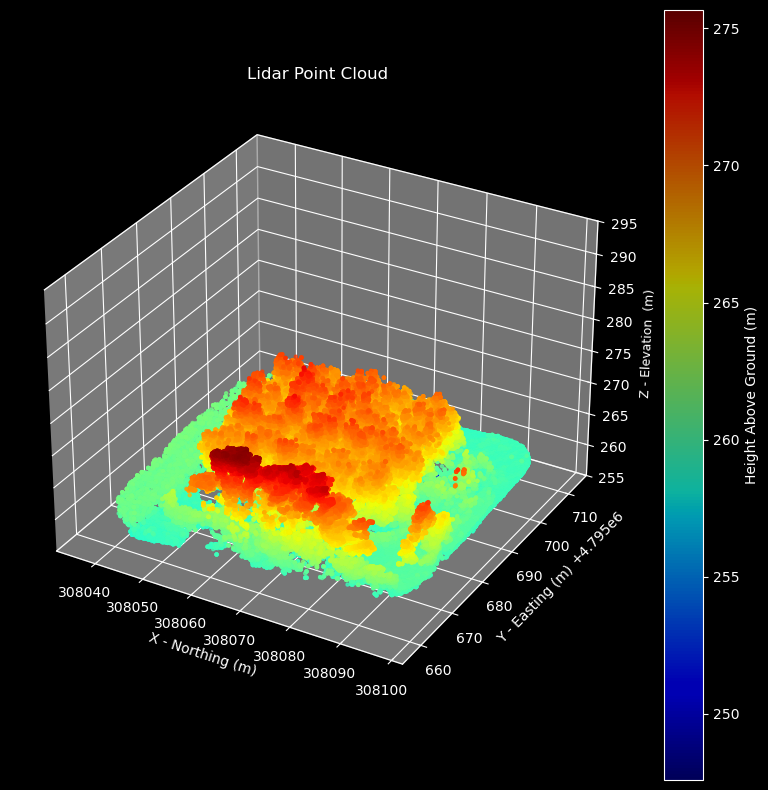

In [151]:
fig,ax = plot_cloud(clip_arrays, zlims=[255,295], zlabel = "Elevation")

### Outliers

The outliers will be Classified with a value of 7.

In [ ]:
# OUTLIER IDENTIFICATION
outlier = pdal.Filter.outlier(method="statistical", multiplier=3, mean_k=8)

### Z limit Range

A very simple way to get rid of outliers is to use a known range to threshold the cloud and drop anything above and below it. It is *critical* to note that at this stage the Z values still represent elevation above sea level (in meters), so the limits should be set accordingly.

With drone fligths, the values can be determined easily while the copter is flying and noted for later use. If not known precisely, these can be estimated with a little trial-and-error beforehand.

The outliers (Classification != 7) can also be dropped (`!=` is not equal to) at the same time with an expression based Filter that will *keep* values that fit these conditions.

In [ ]:
# OUTLIER REMOVAL
outlier_rng = pdal.Filter.expression(
    expression=f"(Classification != 7) && (Z >= {zmin} && Z <= {zmax})"
)

In [ ]:

# 2- Execute pipeline
pipeline.execute()
arrays = pipeline.arrays[0]

## 5. Verify Processing Pipeline

This section will test a basic processing pipeline.

The defaults do not to be edited before running the cell:

In [ ]:
ras_type  = "RGB"
json_name = f"test_colorize_{ras_type}.json"
json_dir  = f"{wd}/data/json"
json_file = f"{json_dir}/{json_name}"


Use the list trick again to see if the directory is where the variable path points.

In [ ]:
!ls -lah $json_dir

total 0
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 23 13:16 .
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 23 11:55 ..


Now, this cell will create a json file in the directory we just listed.

In [ ]:
colorized_las = f"{lidar_dir}/{las_name}_COLORS.las"

content = [
    {
        "type": "readers.las",
        "filename": las_file
    },
    {
        "type": "filters.colorization",
        "raster": rgb_file
    },
    {
        "type": "writers.las",
        "filename": colorized_las,
        "minor_version": "4",
        "dataformat_id": "8",
        "scale_z": "1.0",
        "extra_dims": "all",
        "forward": "all"
    }
]

Write that to file.

In [ ]:
import json

json_content = json.dumps(content, indent=4)

with open(json_file, 'w') as f:
    f.write(json_content)


Now the file should be listed in the directory.

In [ ]:
!ls -lah $json_dir

total 9.0K
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu   0 Apr 23 13:16 .
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu   0 Apr 23 11:55 ..
-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 656 Apr 23 13:16 test_colorize_RGB.json


Using bash again, we can quickly print the contents to the screen with ```cat```. It should appear in the correctly formatted JSON file structure.

In [ ]:
!cat $json_file

[
    {
        "type": "readers.las",
        "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar_cgn.las"
    },
    {
        "type": "filters.colorization",
        "raster": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/tif/ARLINGTON-ARS_20200824_02_Refl_rgb_clip.tif"
    },
    {
        "type": "writers.las",
        "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar_cgn_RGB.las",
        "minor_version": "4",
        "dataformat_id": "8",
        "scale_z": "1.0",
        "extra_dims": "all",
        "forward": "all"
    }
]

Now execute the pipeline to run the tile.

In [ ]:
import pdal

col_pipeline = pdal.Pipeline(json_content)
col_count = col_pipeline.execute()

!ls -lah $colorized_las

-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 65M Apr 23 13:21 /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar_cgn_COLORS.las


## Point-based NDVI
This same step could be used to add more colors from other bands, then use the arrays to create a spectral index (NDVI) as an attribute.

In [ ]:
import pdal

col_pipeline = pdal.Pipeline(json_content)
col_count = col_pipeline.execute()
col_arrays = col_pipeline.arrays[0]
col_metadata = col_pipeline.metadata
col_log = col_pipeline.log

The colors are named in numpy structured array.

In [ ]:
col_arrays["Red"]

array([ 9., 11., 15., ..., 18., 18., 25.], shape=(1792448,))

In [ ]:
import json


content = [
    {
        "type": "readers.las",
        "filename": f"{lidar_dir}/{las_name}_COLORS.las"
    },
    {
        "type": "filters.colorization",
        "dimensions":"SWIR1, SWIR2, SWIR3",
        "raster": swir_file
    },
    {
        "type": "writers.las",
        "filename": f"{lidar_dir}/{las_name}_COLORS.las",
        "minor_version": "4",
        "dataformat_id": "8",
        "scale_z": "1.0",
        "extra_dims": "all",
        "forward": "all"
    }
]

json_content = json.dumps(content, indent=4)

with open(json_file, 'w') as f:
    f.write(json_content)

col_pipeline = pdal.Pipeline(json_content)
col_count = col_pipeline.execute()
col_arrays = col_pipeline.arrays[0]
col_metadata = col_pipeline.metadata
col_log = col_pipeline.log


In [ ]:
import numpy as np

# 1 - Create ndvi points
red = col_arrays['Red'][:]
swir1 = col_arrays['SWIR1'][:]

ndvi = (swir1 - red) / (swir1 + red)

# 2. Define the new data type with the 'NDVI' field
original_dtype = col_arrays.dtype
new_dtype = np.dtype(original_dtype.descr + [('NDVI', ndvi.dtype)])

# 3. Create a new structured array with the new data type
new_col_arrays = np.zeros(col_arrays.shape, dtype=new_dtype)

# 4. Copy the data from the original array to the new array
for name in original_dtype.names:
    new_col_arrays[name] = col_arrays[name]

# 5. Assign the calculated NDVI array to the 'NDVI' field of the new array
new_col_arrays["NDVI"] = ndvi

new_col_arrays

/tmp/ipykernel_2221425/196947031.py:7: RuntimeWarning: invalid value encountered in divide
  ndvi = (swir1 - red) / (swir1 + red)


array([(308050.402, 4795701.488,  0., 63, 2, 3, 0, 0, 2, 0, 0, 0, 0, 0., 2, 0, 1.59828507e+09, 0,  9, 20, 12, 0,  56., 25.,  7., 0.72307692),
       (308050.685, 4795701.717,  0., 63, 2, 3, 0, 0, 2, 0, 0, 0, 0, 0., 2, 0, 1.59828507e+09, 0, 11, 20, 14, 0,  58., 26.,  9., 0.68115942),
       (308050.883, 4795698.372,  7., 63, 2, 3, 0, 0, 4, 0, 0, 0, 0, 0., 2, 0, 1.59828507e+09, 0, 15, 32, 15, 0, 125., 59., 19., 0.78571429),
       ...,
       (308066.618, 4795698.226, 12., 15, 2, 3, 0, 0, 5, 0, 0, 0, 0, 0., 9, 0, 1.59828567e+09, 0, 18, 35, 18, 0, 121., 62., 20., 0.74100719),
       (308066.618, 4795698.226, 12., 15, 1, 3, 0, 0, 5, 0, 0, 0, 0, 0., 9, 0, 1.59828567e+09, 0, 18, 35, 18, 0, 121., 62., 20., 0.74100719),
       (308065.253, 4795696.43 , 12., 16, 2, 3, 0, 0, 5, 0, 0, 0, 0, 0., 9, 0, 1.59828567e+09, 0, 25, 40, 20, 0, 131., 73., 27., 0.67948718)],
      shape=(1792448,), dtype=[('X', '<f8'), ('Y', '<f8'), ('Z', '<f8'), ('Intensity', '<u2'), ('ReturnNumber', 'u1'), ('NumberOfReturn

In [ ]:
# Define a writer to output LAS format
forward_arrays = pdal.Pipeline(arrays = [new_col_arrays])
las_writer     = pdal.Writer(filename=f"{lidar_dir}/{las_name}_NDVI.las", 
                             type="writers.las",
                             minor_version= 4,
                             dataformat_id= 8,
                             scale_z= 1.0,
                             extra_dims= "all",
                             forward= "all")


# Write the array to the LAS file
ndvi_pipeline = forward_arrays | las_writer
ndvi_pipeline.execute()


1792448